📊 BUSINESS PERFORMANCE ANALYSIS

📂 Loading datasets...
✅ Data loaded successfully

🔧 Preparing data...
✅ Data preparation complete

💰 ANALYSIS 1: PAYROLL DISTRIBUTION

📊 Total Monthly Payroll: R$ 2.717.493,22

📋 Payroll by Department:


department
Administrative    R$ 686.016,38
Operations        R$ 606.785,22
Logistics         R$ 563.740,42
Commercial        R$ 524.104,86
Financial         R$ 336.846,34
Name: total_compensation, dtype: object

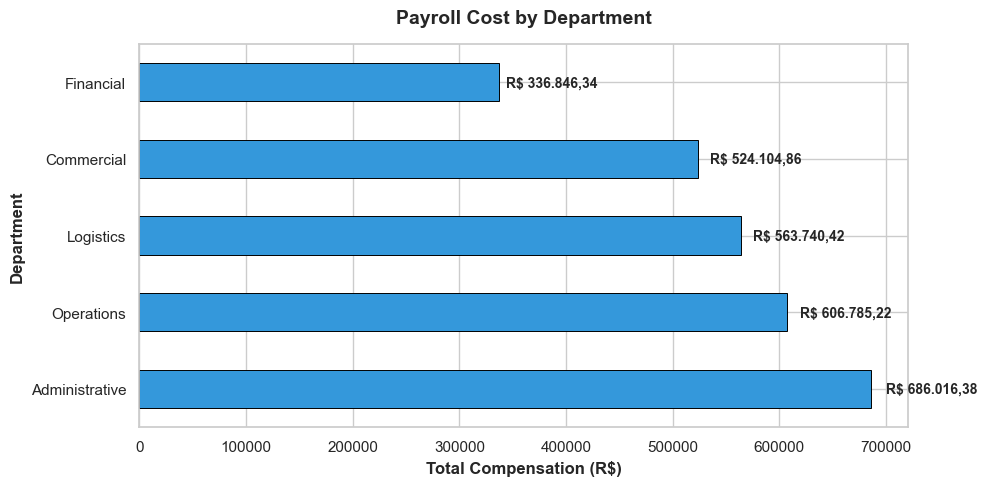


💡 Key Insight:
   Administrative dept has highest payroll (R$ 686.016,38) - automation opportunity

💵 ANALYSIS 2: REVENUE PERFORMANCE

📊 Total Company Revenue: R$ 5.519.160,00

🏆 Top 5 Clients by Revenue:


,client_id,client_name,total_revenue
12,14,Silva Quintana,63000
230,311,Fadel Capistrano,61200
55,76,Celeste Costa,61110
45,57,Vellado Fernandes,61110
52,67,Pereira Mello,60480


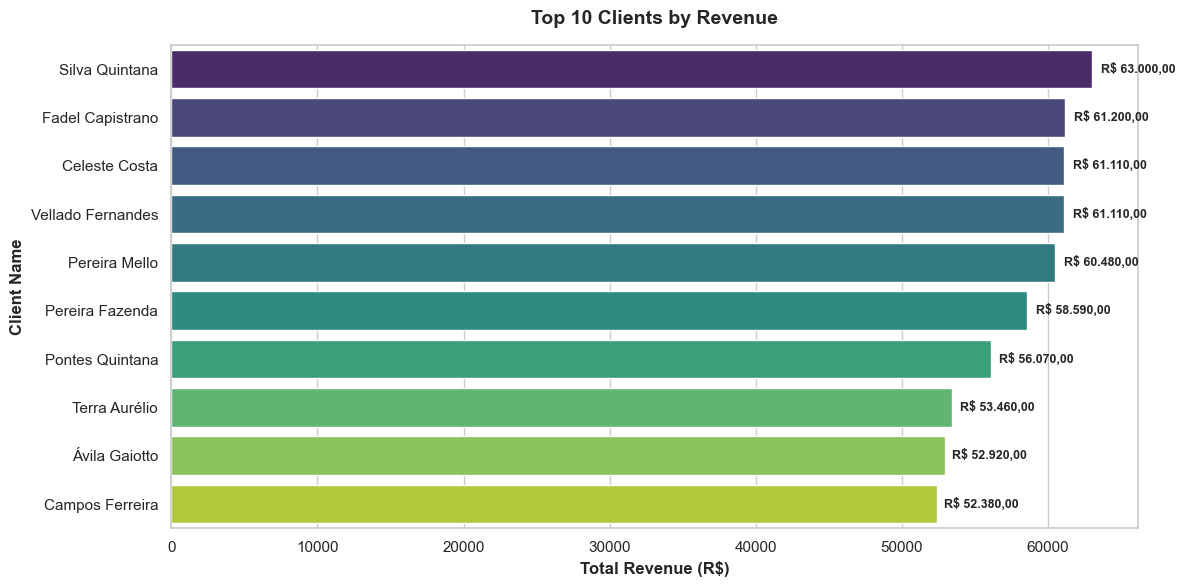


💡 Key Insight:
   Top 3 clients represent 3.4% of revenue - diversification needed

👥 ANALYSIS 3: EMPLOYEE PRODUCTIVITY

📊 Employee Performance Summary:


,Metric,Value
0,Total Employees,114
1,Active (with contracts),99
2,Inactive (no contracts),15
3,Activity Rate,86.8%



💡 Key Insight:
   15 employees (13.2%) without contracts - training opportunity

📋 ANALYSIS 4: DEPARTMENTAL PERFORMANCE

📊 Contracts by Department:


department
Administrative    63
Operations        48
Commercial        44
Financial         42
Logistics         40
Name: count, dtype: int64

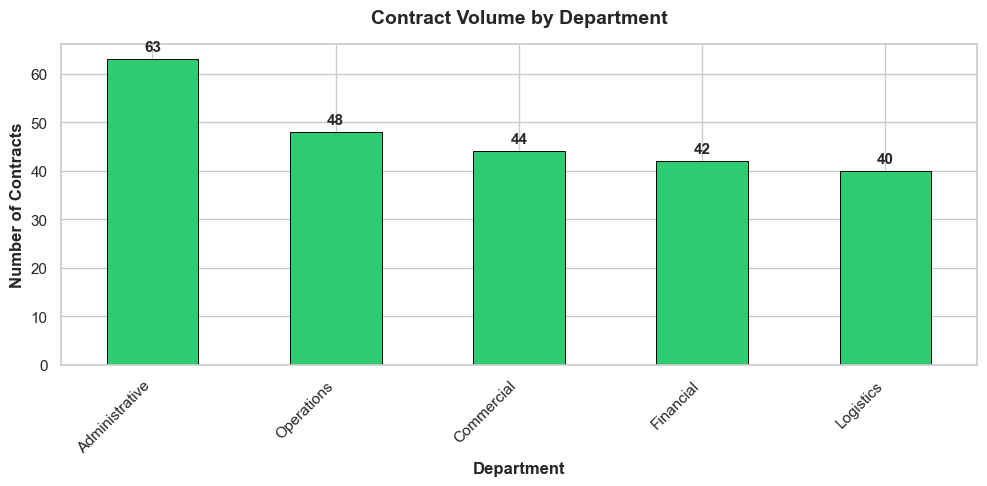


💡 Key Insight:
   Commercial leads with 63 contracts (expected as core function)

👔 ANALYSIS 5: HEADCOUNT ALLOCATION

📊 Employees by Department:


department
Administrative    26
Commercial        26
Operations        23
Logistics         21
Financial         18
Name: count, dtype: int64

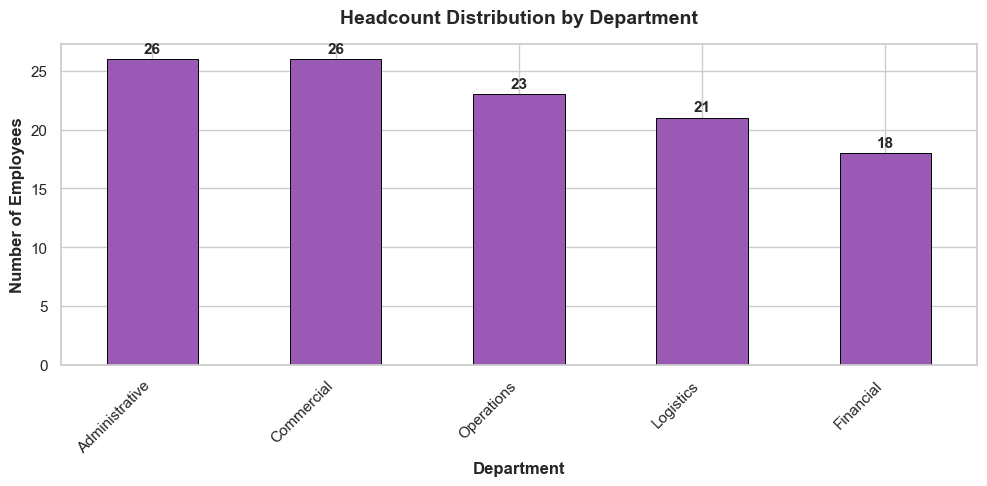


💡 Key Insight:
   Administrative has 26 employees - review workload vs headcount

💰 ANALYSIS 6: CONTRACT VALUE METRICS

📊 Monthly Contract Value Statistics:


,Metric,Value
0,Average,"R$ 2.502,56"
1,Median,"R$ 2.542,50"
2,Minimum,"R$ 450,00"
3,Maximum,"R$ 4.500,00"



💡 Key Insight:
   Average contract R$ 2.502,56 indicates mid-market positioning

📊 EXECUTIVE SUMMARY

FINANCIAL METRICS:
- Total Monthly Payroll: R$ 2.717.493,22
- Total Company Revenue: R$ 5.519.160,00
- Average Contract Value: R$ 2.502,56

OPERATIONAL METRICS:
- Employee Activity Rate: 86.8%
- Inactive Employees: 15 (13.2%)
- Top Revenue Client: Silva Quintana

KEY OPPORTUNITIES:
✅ Reduce Administrative costs through automation
✅ Train 15 inactive employees to increase revenue
✅ Diversify client base (Top 3 = 3.4% of revenue)
✅ Develop tiered pricing (current range: R$ 450,00 - R$ 4.500,00)

STATUS: Strong foundation with clear optimization paths


✅ ANALYSIS COMPLETE - All visualizations saved to outputs/


In [1]:
"""
================================================================================
BUSINESS PERFORMANCE ANALYSIS
================================================================================
Author: Luiz Milaré
Description: Comprehensive analysis of payroll, revenue, and employee performance
Tools: Python, Pandas, Matplotlib, Seaborn
================================================================================
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("=" * 80)
print("📊 BUSINESS PERFORMANCE ANALYSIS")
print("=" * 80)

# ================================================================================
# 1. DATA LOADING
# ================================================================================
print("\n📂 Loading datasets...")

employees_df = pd.read_csv('C:\\Users\\Usuario\\Desktop\\Portfolio\\business-analysis\\data\\employees.csv', sep=';', decimal=',')
clients_df = pd.read_csv('C:\\Users\\Usuario\\Desktop\\Portfolio\\business-analysis\\data\\clients.csv', sep=';', decimal=',')
services_df = pd.read_excel('C:\\Users\\Usuario\\Desktop\\Portfolio\\business-analysis\\data\\services.xlsx')

print("✅ Data loaded successfully")

# ================================================================================
# 2. DATA PREPARATION
# ================================================================================
print("\n🔧 Preparing data...")

# Column translations
employees_column_mapping = {
    'ID Funcionário': 'employee_id',
    'Nome Completo': 'full_name', 
    'Area': 'department',
    'Salario Base': 'base_salary',
    'Impostos': 'taxes',
    'Beneficios': 'benefits',
    'VT': 'transportation_allowance',
    'VR': 'meal_allowance'
}

clients_column_mapping = {
    'ID Cliente': 'client_id',
    'Cliente': 'client_name',
    'Data de Nascimento': 'birth_date',
    'Estado': 'state',
    'Sexo': 'gender',
    'Data de Cadastro': 'registration_date',
    'Profissão': 'profession',
    'Valor Contrato Mensal': 'monthly_contract_value'
}

services_column_mapping = {
    'ID Funcionário': 'employee_id',
    'ID Cliente': 'client_id', 
    'Data do Servico': 'service_date',
    'Tipo da Servico': 'service_type',
    'Valor do Servico': 'service_value',
    'Tempo Total de Contrato (Meses)': 'contract_duration_months',
    'Valor Contrato Mensal': 'monthly_contract_value'
}

department_mapping = {
    'Administrativo': 'Administrative',
    'Comercial': 'Commercial', 
    'Financeiro': 'Financial',
    'Operações': 'Operations', 
    'Logística': 'Logistics'
}

# Apply transformations
employees_df = employees_df.rename(columns=employees_column_mapping)
clients_df = clients_df.rename(columns=clients_column_mapping)
services_df = services_df.rename(columns=services_column_mapping)

employees_df['department'] = employees_df['department'].map(department_mapping)
employees_df = employees_df.drop(['Estado Civil', 'Cargo'], axis=1)

# Calculate total compensation
employees_df['total_compensation'] = (
    employees_df['base_salary'] + 
    employees_df['taxes'] + 
    employees_df['benefits'] + 
    employees_df['transportation_allowance'] + 
    employees_df['meal_allowance']
)

print("✅ Data preparation complete")

# ================================================================================
# HELPER FUNCTION
# ================================================================================

def format_currency_br(value):
    """Format numeric values as Brazilian currency"""
    return f"R$ {value:,.2f}".replace(',', 'x').replace('.', ',').replace('x', '.')

# ================================================================================
# ANALYSIS 1: PAYROLL BY DEPARTMENT
# ================================================================================
print("\n" + "=" * 80)
print("💰 ANALYSIS 1: PAYROLL DISTRIBUTION")
print("=" * 80)

total_payroll = employees_df['total_compensation'].sum()
payroll_by_department = employees_df.groupby('department')['total_compensation'].sum().sort_values(ascending=False)

print(f'\n📊 Total Monthly Payroll: {format_currency_br(total_payroll)}')
print(f'\n📋 Payroll by Department:')
display(payroll_by_department.apply(format_currency_br))

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
payroll_by_department.plot(
    kind='barh', 
    ax=ax,
    color='#3498db',
    edgecolor='black',
    linewidth=0.7
)

ax.set_xlabel('Total Compensation (R$)', fontsize=12, fontweight='bold')
ax.set_ylabel('Department', fontsize=12, fontweight='bold')
ax.set_title('Payroll Cost by Department', fontsize=14, fontweight='bold', pad=15)

# Add value labels
for i, v in enumerate(payroll_by_department.values):
    ax.text(v + (v * 0.02), i, format_currency_br(v), 
            va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/payroll_by_department.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n💡 Key Insight:')
print(f'   Administrative dept has highest payroll ({format_currency_br(payroll_by_department.iloc[0])}) - automation opportunity')

# ================================================================================
# ANALYSIS 2: REVENUE ANALYSIS
# ================================================================================
print("\n" + "=" * 80)
print("💵 ANALYSIS 2: REVENUE PERFORMANCE")
print("=" * 80)

# Calculate revenue
revenue_df = (
    services_df[['client_id', 'contract_duration_months']]
    .merge(clients_df[['client_id', 'monthly_contract_value']], on='client_id')
)
revenue_df['total_revenue'] = (
    revenue_df['contract_duration_months'] * revenue_df['monthly_contract_value']
)

total_revenue = revenue_df['total_revenue'].sum()

# Top clients
revenue_by_client = (
    revenue_df.merge(clients_df[['client_id','client_name']], on='client_id')
    .groupby(['client_id', 'client_name'])['total_revenue']
    .sum()
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print(f'\n📊 Total Company Revenue: {format_currency_br(total_revenue)}')
print(f'\n🏆 Top 5 Clients by Revenue:')
display(revenue_by_client.head(5))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
top_10_clients = revenue_by_client.head(10)

sns.barplot(
    data=top_10_clients,
    y='client_name',
    x='total_revenue',
    palette='viridis',
    ax=ax,
    hue='client_name',
    legend=False
)

ax.set_title('Top 10 Clients by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (R$)', fontsize=12, fontweight='bold')
ax.set_ylabel('Client Name', fontsize=12, fontweight='bold')

# Add value labels
for i, v in enumerate(top_10_clients['total_revenue']):
    ax.text(v + (v * 0.01), i, format_currency_br(v), 
            va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/top_10_clients.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate concentration
top_3_revenue = revenue_by_client.head(3)['total_revenue'].sum()
concentration_pct = (top_3_revenue / total_revenue) * 100

print(f'\n💡 Key Insight:')
print(f'   Top 3 clients represent {concentration_pct:.1f}% of revenue - diversification needed')

# ================================================================================
# ANALYSIS 3: EMPLOYEE PERFORMANCE
# ================================================================================
print("\n" + "=" * 80)
print("👥 ANALYSIS 3: EMPLOYEE PRODUCTIVITY")
print("=" * 80)

employees_with_contracts = services_df['employee_id'].nunique()
total_employees = employees_df['employee_id'].nunique()
percentage_active = (employees_with_contracts / total_employees) * 100
inactive_employees = total_employees - employees_with_contracts

# Summary table
performance_summary = pd.DataFrame({
    'Metric': ['Total Employees', 'Active (with contracts)', 'Inactive (no contracts)', 'Activity Rate'],
    'Value': [
        total_employees, 
        employees_with_contracts, 
        inactive_employees, 
        f'{percentage_active:.1f}%'
    ]
})

print('\n📊 Employee Performance Summary:')
display(performance_summary)

print(f'\n💡 Key Insight:')
print(f'   {inactive_employees} employees ({100-percentage_active:.1f}%) without contracts - training opportunity')

# ================================================================================
# ANALYSIS 4: CONTRACTS BY DEPARTMENT
# ================================================================================
print("\n" + "=" * 80)
print("📋 ANALYSIS 4: DEPARTMENTAL PERFORMANCE")
print("=" * 80)

contracts_by_dept_df = services_df.merge(
    employees_df[['employee_id', 'department']],
    on='employee_id',
    how='left'
)

contracts_by_department = contracts_by_dept_df['department'].value_counts().sort_values(ascending=False)

print('\n📊 Contracts by Department:')
display(contracts_by_department)

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
contracts_by_department.plot(
    kind='bar',
    ax=ax,
    color='#2ecc71',
    edgecolor='black',
    linewidth=0.7
)

ax.set_title('Contract Volume by Department', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Contracts', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Add value labels
for i, v in enumerate(contracts_by_department.values):
    ax.text(i, v + 1, f'{v}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/contracts_by_department.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n💡 Key Insight:')
print(f'   Commercial leads with {contracts_by_department.iloc[0]} contracts (expected as core function)')

# ================================================================================
# ANALYSIS 5: HEADCOUNT DISTRIBUTION
# ================================================================================
print("\n" + "=" * 80)
print("👔 ANALYSIS 5: HEADCOUNT ALLOCATION")
print("=" * 80)

employees_by_department = employees_df['department'].value_counts().sort_values(ascending=False)

print('\n📊 Employees by Department:')
display(employees_by_department)

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
employees_by_department.plot(
    kind='bar',
    ax=ax,
    color='#9b59b6',
    edgecolor='black',
    linewidth=0.7
)

ax.set_title('Headcount Distribution by Department', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Employees', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Add value labels
for i, v in enumerate(employees_by_department.values):
    ax.text(i, v + 0.3, f'{v}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/headcount_by_department.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n💡 Key Insight:')
print(f'   {employees_by_department.index[0]} has {employees_by_department.iloc[0]} employees - review workload vs headcount')

# ================================================================================
# ANALYSIS 6: CONTRACT VALUE ANALYSIS
# ================================================================================
print("\n" + "=" * 80)
print("💰 ANALYSIS 6: CONTRACT VALUE METRICS")
print("=" * 80)

average_contract = clients_df['monthly_contract_value'].mean()
median_contract = clients_df['monthly_contract_value'].median()
min_contract = clients_df['monthly_contract_value'].min()
max_contract = clients_df['monthly_contract_value'].max()

contract_metrics = pd.DataFrame({
    'Metric': ['Average', 'Median', 'Minimum', 'Maximum'],
    'Value': [
        format_currency_br(average_contract),
        format_currency_br(median_contract),
        format_currency_br(min_contract),
        format_currency_br(max_contract)
    ]
})

print('\n📊 Monthly Contract Value Statistics:')
display(contract_metrics)

print(f'\n💡 Key Insight:')
print(f'   Average contract {format_currency_br(average_contract)} indicates mid-market positioning')

# ================================================================================
# EXECUTIVE SUMMARY
# ================================================================================
print("\n" + "=" * 80)
print("📊 EXECUTIVE SUMMARY")
print("=" * 80)

summary = f"""
FINANCIAL METRICS:
- Total Monthly Payroll: {format_currency_br(total_payroll)}
- Total Company Revenue: {format_currency_br(total_revenue)}
- Average Contract Value: {format_currency_br(average_contract)}

OPERATIONAL METRICS:
- Employee Activity Rate: {percentage_active:.1f}%
- Inactive Employees: {inactive_employees} ({100-percentage_active:.1f}%)
- Top Revenue Client: {revenue_by_client.iloc[0]['client_name']}

KEY OPPORTUNITIES:
✅ Reduce Administrative costs through automation
✅ Train {inactive_employees} inactive employees to increase revenue
✅ Diversify client base (Top 3 = {concentration_pct:.1f}% of revenue)
✅ Develop tiered pricing (current range: {format_currency_br(min_contract)} - {format_currency_br(max_contract)})

STATUS: Strong foundation with clear optimization paths
"""

print(summary)

print("\n" + "=" * 80)
print("✅ ANALYSIS COMPLETE - All visualizations saved to outputs/")
print("=" * 80)